# Machine Learning

### Bibliotecas

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## 1. Regressão — Student Performance

In [71]:
train_df = pd.read_csv(r'C:\Analytica\Git\ufrj-analytica-training\entregaveis\machine_learning\regressao\train.csv')
test_df = pd.read_csv(r'C:\Analytica\Git\ufrj-analytica-training\entregaveis\machine_learning\regressao\test.csv')

### 1.1 EDA

In [72]:
train_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,score
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,6,5.67
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,4,5.33
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,10,8.33
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,2,14.67
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,4,8.67
5,GP,M,16,U,LE3,T,4,3,services,other,...,yes,no,5,4,2,1,2,5,10,15.00
6,GP,M,16,U,LE3,T,2,2,other,other,...,yes,no,4,4,4,1,1,3,0,11.67
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,no,no,4,1,4,1,1,1,6,5.67
8,GP,M,15,U,LE3,A,3,2,services,other,...,yes,no,4,2,2,1,1,1,0,17.67
9,GP,M,15,U,GT3,T,3,4,other,other,...,yes,no,5,5,1,1,1,5,0,14.67


In [73]:
train_df.info(verbose=True)
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      395 non-null    object 
 1   sex         395 non-null    object 
 2   age         395 non-null    int64  
 3   address     395 non-null    object 
 4   famsize     395 non-null    object 
 5   Pstatus     395 non-null    object 
 6   Medu        395 non-null    int64  
 7   Fedu        395 non-null    int64  
 8   Mjob        395 non-null    object 
 9   Fjob        395 non-null    object 
 10  reason      395 non-null    object 
 11  guardian    395 non-null    object 
 12  traveltime  395 non-null    int64  
 13  studytime   395 non-null    int64  
 14  failures    395 non-null    int64  
 15  schoolsup   395 non-null    object 
 16  famsup      395 non-null    object 
 17  paid        395 non-null    object 
 18  activities  395 non-null    object 
 19  nursery     395 non-null    o

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,score
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.679139
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.696912
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.330000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.330000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,10.670000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.330000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.330000


In [74]:
train_df.dtypes

school         object
sex            object
age             int64
address        object
famsize        object
Pstatus        object
Medu            int64
Fedu            int64
Mjob           object
Fjob           object
reason         object
guardian       object
traveltime      int64
studytime       int64
failures        int64
schoolsup      object
famsup         object
paid           object
activities     object
nursery        object
higher         object
internet       object
romantic       object
famrel          int64
freetime        int64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
score         float64
dtype: object

In [75]:
train_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'score'],
      dtype='object')

C:\Users\eduar\AppData\Local\Temp\ipykernel_21024\143798046.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\eduar\AppData\Local\Temp\ipykernel_21024\143798046.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\eduar\AppData\Local\Temp\ipykernel_21024\143798046.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




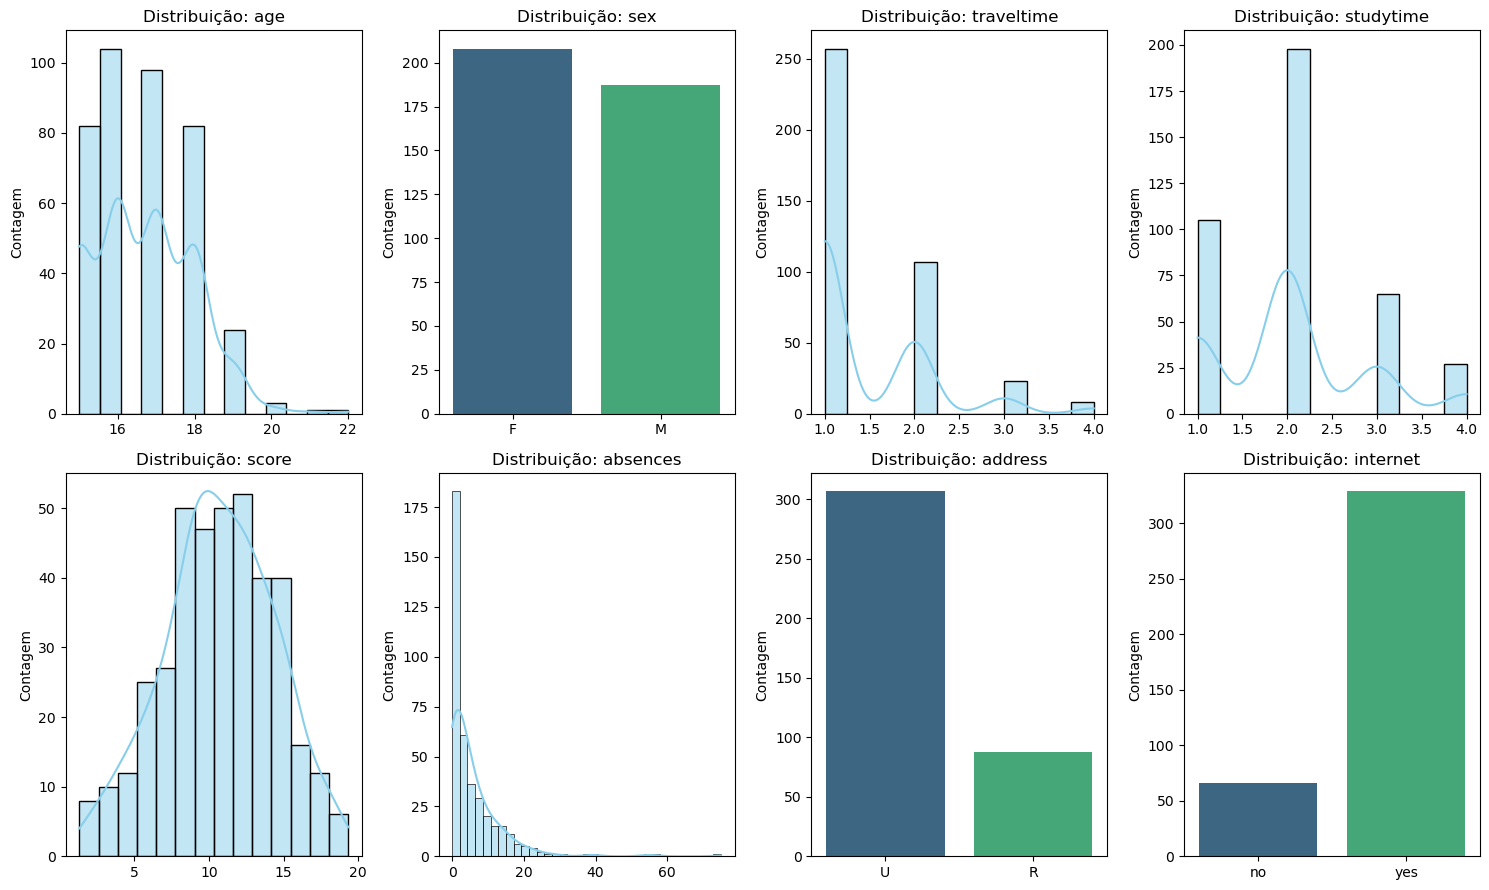

In [76]:
colunas = ['age', 'sex', 'traveltime', 'studytime', 'score', 'absences', 'address', 'internet']


fig, axes = plt.subplots(2, 4, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(colunas):
    if train_df[col].dtype == 'object':
        sns.countplot(data=train_df, x=col, ax=axes[i], palette='viridis')
    else:
        sns.histplot(data=train_df, x=col, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Contagem')
plt.tight_layout()
plt.show()

In [77]:
print(train_df.isnull().values.any())

False


In [78]:
colunas2 = ['age', 'traveltime', 'studytime', 'score', 'absences']

fig = make_subplots(rows=2, cols=3, subplot_titles=colunas2)

posicoes = [(1,1), (1,2), (1,3), (2,1), (2,2)]

for col, (row, c) in zip(colunas2, posicoes):
    fig.add_trace(
        go.Box(y=train_df[col], name=col, boxpoints='outliers'),
        row=row, col=c
    )

fig.update_layout(height=700, width=1000, title_text="Distribuição por Coluna (Plotly)", showlegend=False)
fig.show()

### 1.2 Limpeza e pré-processamento

Podemos transformar as variáveis categóricas em numéricas para testar se os modelos futuros de ML performam melhor, além de normalizar algumas delas.

In [79]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [80]:
train_df2 = pd.get_dummies(train_df, drop_first=True)

Transformando as colunas de texto ou categóricas em numéricas.

In [81]:
n_train = len(train_df) # Contar até onde a tabela train_df vai para não misturar com o test_df quando separar.
df_full = pd.concat([train_df, test_df], axis=0, ignore_index=True)
df_full_dummies = pd.get_dummies(df_full, drop_first=True)

In [82]:
train_df2 = df_full_dummies.iloc[:n_train].copy()
test_df2 = df_full_dummies.iloc[n_train:].copy()

if 'score' in test_df2.columns:
    test_df2 = test_df2.drop(columns=['score'])

In [83]:
predictors = train_df2.drop(columns=['score'])
target = train_df2['score']

In [84]:
scaler = StandardScaler()

# Treinar no train e criar train_df3
predictors_esc = scaler.fit_transform(predictors)
train_df3 = pd.DataFrame(predictors_esc, columns=predictors.columns)
train_df3['score'] = target.values

# Transformar o test e criar test_df3
test_esc = scaler.transform(test_df2)
test_df3 = pd.DataFrame(test_esc, columns=predictors.columns)

### 1.3 Modelo de inferência.

In [85]:
# Modelos do Scikit-Learn
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV

In [86]:
X2 = train_df2.drop(columns=['score'])
y2 = train_df2['score']

X3 = train_df3.drop(columns=['score'])
y3 = train_df3['score']

## Definição de Hiperparâmetros

In [87]:
param_lr = {}

param_elastic = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [1000, 2000]
}

param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

param_svr = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'epsilon': [0.01, 0.1, 0.2, 0.5]
}

param_dt = {
    'max_depth': [None, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

param_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

param_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

param_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [88]:
modelos_completos = {
    'Linear Regression': (LinearRegression(), param_lr, X3, y3),
    'ElasticNet': (ElasticNet(random_state=42), param_elastic, X3, y3),
    'KNN': (KNeighborsRegressor(), param_knn, X3, y3),
    'SVR': (SVR(), param_svr, X3, y3),
    'Decision Tree': (DecisionTreeRegressor(random_state=42), param_dt, X2, y2),
    'Random Forest': (RandomForestRegressor(random_state=42), param_rf, X2, y2),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42), param_gb, X2, y2),
    'XGBoost': (XGBRegressor(random_state=42), param_xgb, X2, y2)
}

resultados_completos = []
melhores_modelos = {}

In [89]:
for nome, (modelo, espaco_params, X_dados, y_dados) in modelos_completos.items():
    n_iteracoes = 1 if len(espaco_params) == 0 else 20
    search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=espaco_params if len(espaco_params) > 0 else {},
        n_iter=n_iteracoes,
        cv=5,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_dados, y_dados)
    rmse_otimizado = np.sqrt(-search.best_score_)

    resultados_completos.append({
        'Modelo': nome,
        'RMSE Otimizado': rmse_otimizado,
        'Melhores Parâmetros': search.best_params_
    })

    melhores_modelos[nome] = search.best_estimator_

In [90]:
df_ranking_otimizado = pd.DataFrame(resultados_completos).sort_values(by='RMSE Otimizado').reset_index(drop=True)

print("=== RANKING FINAL DE MODELOS OTIMIZADOS ===")
display(df_ranking_otimizado[['Modelo', 'RMSE Otimizado']])

=== RANKING FINAL DE MODELOS OTIMIZADOS ===


,Modelo,RMSE Otimizado
0,Random Forest,3.368757
1,Gradient Boosting,3.412543
2,XGBoost,3.432335
3,ElasticNet,3.463458
4,Decision Tree,3.524737
5,SVR,3.554759
6,Linear Regression,3.568045
7,KNN,3.605335


## Previsão do Score

In [91]:
# 1. Filtrar o dicionário mantendo apenas os 3 melhores modelos
modelos_top3 = {
    k: v
    for k, v in modelos_completos.items()
    if k in ['Random Forest', 'Gradient Boosting', 'XGBoost']
}

df_previsoes_finais = pd.DataFrame()

if 'id' in test_df.columns:
    df_previsoes_finais['id'] = test_df['id'].values

# Resetar estruturas de apoio se necessário
resultados_completos = []
melhores_modelos = {}

# 2. Iteração acelerada com RandomizedSearchCV
for nome_modelo, (
    modelo,
    param_grid,
    X_treino,
    y_treino,
) in modelos_top3.items():

    # Troca do Grid pelo RandomizedSearchCV para reduzir combinações desnecessárias
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_grid,
        n_iter=10,  # Testa apenas 10 combinações promissoras por modelo
        cv=3,  # Reduzido para 3-fold (3x mais rápido que 5-fold)
        scoring='neg_mean_squared_error',
        n_jobs=-1,  # Usa todos os núcleos da CPU
        random_state=42,
    )
    random_search.fit(X_treino, y_treino)

    # Armazena o melhor modelo ajustado
    melhor_modelo = random_search.best_estimator_
    melhores_modelos[nome_modelo] = melhor_modelo

    # Salva os resultados do tuning
    resultados_completos.append({
        'Modelo': nome_modelo,
        'Melhor_Score': random_search.best_score_,
        'Melhores_Parametros': random_search.best_params_,
    })

    # Seleção do dataset correspondente (X2 -> test_df2 | X3 -> test_df3)
    df_teste = test_df2 if X_treino is X2 else test_df3

    # Alinhamento de colunas e predição no teste
    df_teste_alinhado = df_teste[X_treino.columns]

    nome_coluna = f"score_{nome_modelo.lower().replace(' ', '_')}"
    df_previsoes_finais[nome_coluna] = melhor_modelo.predict(df_teste_alinhado)

# Exibe o resultado rápido
print(df_previsoes_finais.head())

   score_random_forest  score_gradient_boosting  score_xgboost
0             6.433733                 6.092285       8.044697
1            11.609202                11.417954      11.340752
2             8.696865                 9.301683       9.940999
3            12.575976                12.606553      11.957466
4            10.435185                10.921541      10.872094


## 2. Classificação — Breast Cancer

In [92]:
test = pd.read_csv(r'C:\Analytica\Git\ufrj-analytica-training\entregaveis\machine_learning\classiicacao\test2.csv')
train = pd.read_csv(r'C:\Analytica\Git\ufrj-analytica-training\entregaveis\machine_learning\classiicacao\train2.csv')

### 2.1 EDA

In [93]:
train.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [94]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

### 2.2 Limpeza e pré-processamento

In [96]:
train.drop(['Unnamed: 32','id'], axis=1, inplace=True)

KeyError: "['Unnamed: 32', 'id'] not found in axis"

In [97]:
train

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [98]:
train.isnull().sum().sum()
# sem nenhum valor nulo

np.int64(0)

In [99]:
train.isna().sum().sum()

np.int64(0)

In [100]:
train['diagnosis'] = (train['diagnosis'] == 'M').astype(int) # transformar coluna diagnosis em binário

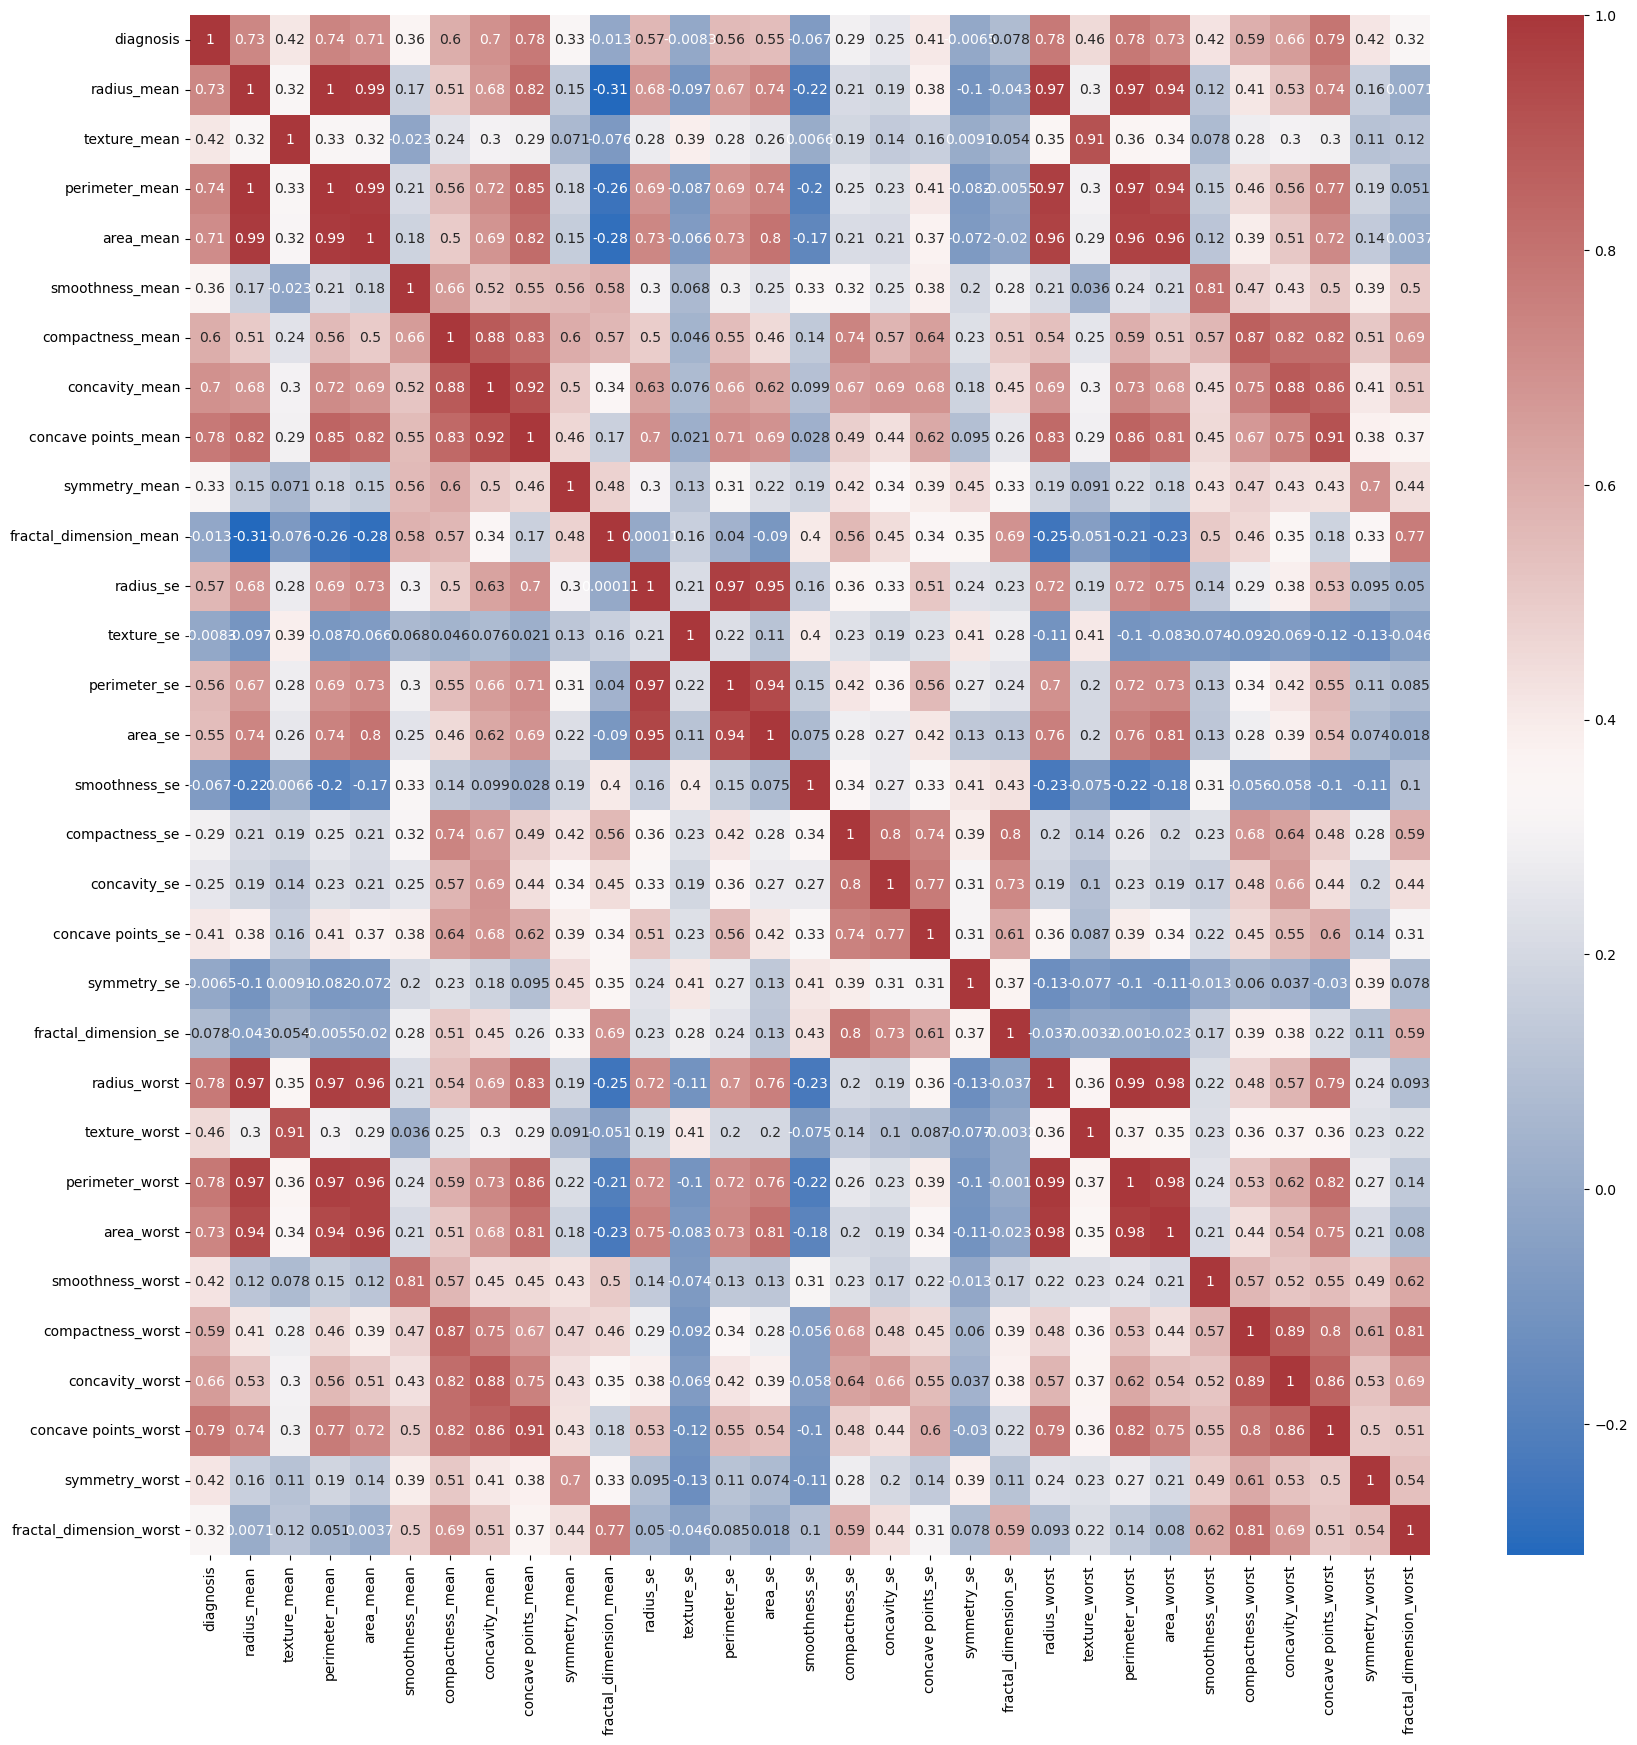

In [ ]:
corr = train.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='vlag',annot=True)
plt.show()

In [ ]:
train.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

### 2.3 Modelo de inferência

In [102]:
target = train.iloc[:,0] #select the target column
target

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [103]:
predictors = train.iloc[:, 1:] #select the predictors column
predictors

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# Division between test and train

In [104]:
from sklearn.model_selection import train_test_split

In [105]:
X = predictors
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

### **StandardScaler + Pipeline**

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
from sklearn.pipeline import Pipeline

def make_pipeline(model, use_scaler=True):
    steps = []
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

# **Naive**

In [108]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, cross_validate

In [109]:
pipe_nb = make_pipeline(GaussianNB(),  use_scaler=True)

Cross Validate

In [110]:
kfold = KFold(n_splits=20, shuffle=True, random_state=0)

result_nb = cross_validate(
    pipe_nb,
    X_train,
    y_train,
    cv=kfold,
    return_train_score=True
)

print("Train:", result_nb['train_score'].mean())
print("Test:", result_nb['test_score'].mean())

Train: 0.9477164592421522
Test: 0.9471343873517786


In [111]:
pipe_nb.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,priors,None
,var_smoothing,1e-09


Predict

In [112]:
y_pred_naive = pipe_nb.predict(X_test)

Accuracy score

In [113]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [114]:
print("Test accuracy:", accuracy_score(y_test, y_pred_naive))

Test accuracy: 0.9035087719298246


In [115]:
predictors_train_naive = pipe_nb.predict(X_train)
accuracy_score(y_train,predictors_train_naive)

0.9472527472527472

In [116]:
print(confusion_matrix(y_test, y_pred_naive))

print(classification_report(y_test, y_pred_naive))

[[61  6]
 [ 5 42]]
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        67
           1       0.88      0.89      0.88        47

    accuracy                           0.90       114
   macro avg       0.90      0.90      0.90       114
weighted avg       0.90      0.90      0.90       114



# **Results**

use_scaler = True

Best Cross Train: 94.78% Train:

Best Cross Test: 94.03%

Test accuracy: 92.98%


# **SVC**

In [117]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [118]:
pipe_SVC = make_pipeline(SVC(),  use_scaler=False)

Grid Search

In [119]:
params = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 2, 5, 10]
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [0.1, 1, 2, 5, 10],
        'model__gamma': ['scale', 'auto']
    }
]

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=0)

grid = GridSearchCV(
    pipe_SVC,
    params,
    cv=kfold,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"[{'model__C': [0.1, 1, ...], 'model__kernel': ['linear']}, {'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['rbf']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,5


In [122]:
grid.best_params_

{'model__C': 5, 'model__kernel': 'linear'}

Grid Analysis

In [ ]:
result = pd.DataFrame(grid.cv_results_)
result = result[['rank_test_score','params','mean_test_score']]
result.sort_values(by='rank_test_score')

# we choose {'model__C': 0.1, 'model__kernel': 'linear'} as a simpler and more balanced model with better generalization

,rank_test_score,params,mean_test_score
3,1,"{'model__C': 5, 'model__kernel': 'linear'}",0.960573
2,2,"{'model__C': 2, 'model__kernel': 'linear'}",0.958300
4,3,"{'model__C': 10, 'model__kernel': 'linear'}",0.956028
0,4,"{'model__C': 0.1, 'model__kernel': 'linear'}",0.951680
1,5,"{'model__C': 1, 'model__kernel': 'linear'}",0.951680
11,6,"{'model__C': 5, 'model__gamma': 'scale', 'mode...",0.916700
13,7,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.916601
9,8,"{'model__C': 2, 'model__gamma': 'scale', 'mode...",0.909980
7,9,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.903261
5,10,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.890119


Apply the best SVC Algo

In [124]:
pipe_SVC = SVC(kernel='linear', C=0.1, random_state=0)

Train

In [125]:
pipe_SVC.fit(X_train,y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Predict

In [126]:
y_pred_SVC = pipe_SVC.predict(X_test)

Accuracy score

In [127]:
accuracy_score(y_test, y_pred_SVC)

0.9298245614035088

In [128]:
predictors_train_SVC = pipe_SVC.predict(X_train)
accuracy_score(y_train, predictors_train_SVC)

0.9692307692307692

In [129]:
print(confusion_matrix(y_test, y_pred_SVC))

print(classification_report(y_test, y_pred_SVC))

[[62  5]
 [ 3 44]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        67
           1       0.90      0.94      0.92        47

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



# **Results**

use_scaler = True

Best Grid Test: 97.81%

Test accuracy: 92.98%

# **XGBOOST**

In [130]:
from xgboost import XGBClassifier

Grid Search

In [137]:
params = {
    'model__learning_rate':[0.1,0.5,1],
   'model__max_depth':[3,4,5],
    'model__n_estimators':[150,200,250]
}

In [138]:
pipe_xg = make_pipeline(XGBClassifier(objective='binary:logistic', random_state = 0),  use_scaler=True)

In [139]:
from sklearn.model_selection import GridSearchCV, KFold

kfold = KFold(n_splits=2, shuffle=True, random_state=0)

grid = GridSearchCV(
    pipe_xg,
    params,
    cv=kfold,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.1, 0.5, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [150, 200, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [140]:
grid.best_params_

{'model__learning_rate': 0.5,
 'model__max_depth': 4,
 'model__n_estimators': 150}

Grid Analysis

In [ ]:
result = pd.DataFrame(grid.cv_results_)
result = result[['rank_test_score','params','mean_test_score']]
result = result.sort_values(by='rank_test_score')
pd.set_option('display.max_colwidth', None)
result['params']
result.head(30)

# since the dataset is relatively easy and many configurations achieve the same score,
# we choose {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200} as a more balanced option to avoid unnecessary complexity

,rank_test_score,params,mean_test_score
13,1,"{'model__learning_rate': 0.5, 'model__max_depth': 4, 'model__n_estimators': 200}",0.962642
12,1,"{'model__learning_rate': 0.5, 'model__max_depth': 4, 'model__n_estimators': 150}",0.962642
14,1,"{'model__learning_rate': 0.5, 'model__max_depth': 4, 'model__n_estimators': 250}",0.962642
9,4,"{'model__learning_rate': 0.5, 'model__max_depth': 3, 'model__n_estimators': 150}",0.960459
10,4,"{'model__learning_rate': 0.5, 'model__max_depth': 3, 'model__n_estimators': 200}",0.960459
11,4,"{'model__learning_rate': 0.5, 'model__max_depth': 3, 'model__n_estimators': 250}",0.960459
2,7,"{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 250}",0.960449
4,8,"{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}",0.960439
5,8,"{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 250}",0.960439
8,8,"{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 250}",0.960439


Apply the best Algo

In [142]:
pipe_xg = XGBClassifier(objective = 'binary:logistic', learning_rate = 0.01, max_depth = 5, n_estimators = 180, random_state = 0)

Train

In [143]:
pipe_xg.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


Predict

In [144]:
y_pred_xg = pipe_xg.predict(X_test)

Accuracy Score

In [145]:
accuracy_score(y_pred_xg, y_test)

0.956140350877193

In [146]:
predict_train = pipe_xg.predict(X_train)
accuracy_score(y_train,predict_train)

0.9934065934065934

In [147]:
print(confusion_matrix(y_test, y_pred_xg))

print(classification_report(y_test, y_pred_xg))

[[64  3]
 [ 2 45]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        67
           1       0.94      0.96      0.95        47

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

